_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: yellow'>*URMI JANA, FRAUKE von de HAAR* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Neural Data Science Project — Spike Inference

## Inferring spiking activity from calcium imaging data using deep learning

In this project you will train your own deep network to infer neuronal spiking activity from calcium imaging ΔF/F traces. You will work with ground truth data from simultaneous calcium imaging and electrophysiology recordings, preprocess it for training, build and train a neural network, and evaluate your model on held-out neurons.

You are free to use tools, resources and libraries as you see fit. Use comments and markdown cells to document your thought process and to explain your reasoning. We encourage you to compare different algorithms or to implement state of the art solutions. The notebook should be self contained, although you may offload some functions to a `utils.py`. The notebook should be concluded with a final summary / conclusions section.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample
from scipy.stats import pearsonr
import scipy.io as sio

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import os, warnings, sys
import glob

import ruamel.yaml as yaml
yaml = yaml.YAML(typ='rt')

CASCADE_DIR   = "../CascadeTorch"
MODEL_FOLDER  = os.path.join(CASCADE_DIR, "Pretrained_models")
GT_FOLDER     = os.path.join(CASCADE_DIR, "Ground_truth")
if CASCADE_DIR not in sys.path:
    sys.path.insert(0, CASCADE_DIR)

from cascade2p import cascade, utils, checks
checks.check_packages()
from cascade2p.utils import plot_dFF_traces, plot_noise_level_distribution, plot_noise_matched_ground_truth

	YAML reader installed (version 0.19.1).
	Torch installed (version 2.5.1+cpu).


## Context

### Calcium imaging and spike inference

Two-photon calcium imaging records neural activity by measuring fluorescence of genetically encoded calcium indicators (e.g. GCaMP6f, GCaMP6s). When a neuron fires an action potential, calcium flows into the cell, causing the indicator to fluoresce more brightly. The resulting signal — expressed as **ΔF/F** (relative fluorescence change) — is a noisy, temporally smoothed version of the true spiking activity:

- A single action potential produces a fast rise (~50 ms) followed by a slow exponential decay (~200–1000 ms, depending on the indicator)
- The signal is corrupted by shot noise, neuropil contamination, and motion artifacts
- Multiple spikes in quick succession sum nonlinearly

**Spike inference** (also called deconvolution) is the inverse problem of recovering the underlying spike times or spike rates from the observed ΔF/F traces.

### Cascade as a reference

In this project you will train your own neural network for the task of spike inference, similar to what was done in [**Cascade**](https://github.com/HelmchenLabSoftware/Cascade) (Rupprecht et al., *Nature Neuroscience*, 2021). Cascade trains a simple 1D convolutional network (~50k parameters) on a large database of simultaneous calcium imaging and electrophysiology recordings. A key part of their approach is a noise-matched training procedure that resamples the ground truth data to match the noise level and frame rate of any target recording, making the trained models robust across different experimental conditions. Cascade also provides pretrained models for common configurations that can serve as performance baselines.

You can use their code, preprocessing routines, and pretrained models as a reference. The PyTorch implementation is available at [CascadeTorch](https://github.com/PTRRupprecht/CascadeTorch).

**Paper:** Rupprecht P, Carta S, Hoffmann A, Echizen M, Blot A, Kwan AC, Dan Y, Hofer SB, Kitamura K, Helmchen F\*, Friedrich RW\*. *A database and deep learning toolbox for noise-optimized, generalized spike inference from calcium imaging.* Nature Neuroscience (2021). [Link](https://www.nature.com/articles/s41593-021-00895-5)

### The data

The file `spike_inference_data.npz` contains ground truth recordings from simultaneous calcium imaging and electrophysiology. Each recording provides:

| Field | Description |
|---|---|
| `dff` | ΔF/F fluorescence trace (1D float array) |
| `t` | Time vector in seconds (1D float array) |
| `spikes` | Action potential times in seconds (1D float array) |
| `frame_rates` | Imaging frame rate in Hz (scalar) |
| `datasets` | Source dataset identifier (string) |

The data is split into:

- **Training recordings** (`train_*`): Use these to build your preprocessing pipeline and train your network. They come from 4 ground truth datasets recorded with GCaMP6f and GCaMP6s in mouse visual cortex.
- **Test recordings** (`test_*`): A held-out dataset for final evaluation. Do not use these for training.

All recordings were obtained at ~60 Hz and can be resampled to a lower frame rate (e.g. 30 Hz) during preprocessing.

In [37]:
# load data
def load_data(path="data"):
    data = np.load(path + "/spike_inference_data.npz", allow_pickle=True)
    return dict(data)

def print_info(data):
    for key in sorted(data.keys()):
        arr = data[key]
        if arr.dtype == object:
            print(f"  [{key:25s}]  {arr.shape}  (variable-length arrays)")
        else:
            print(f"  [{key:25s}]  {arr.shape}  dtype={arr.dtype}")

data = load_data()

print("Overview of the data")
print_info(data)
print(f"\nTraining datasets: {list(data['train_dataset_names'])}")
print(f"Test datasets:     {list(data['test_dataset_names'])}")
print(f"Training recordings: {len(data['train_dff'])}")
print(f"Test recordings:     {len(data['test_dff'])}")

Overview of the data
  [test_dataset_names       ]  (1,)  dtype=<U17
  [test_datasets            ]  (9,)  (variable-length arrays)
  [test_dff                 ]  (9,)  (variable-length arrays)
  [test_filenames           ]  (9,)  (variable-length arrays)
  [test_frame_rates         ]  (9,)  dtype=float64
  [test_spikes              ]  (9,)  (variable-length arrays)
  [test_t                   ]  (9,)  (variable-length arrays)
  [train_dataset_names      ]  (4,)  dtype=<U36
  [train_datasets           ]  (83,)  (variable-length arrays)
  [train_dff                ]  (83,)  (variable-length arrays)
  [train_filenames          ]  (83,)  (variable-length arrays)
  [train_frame_rates        ]  (83,)  dtype=float64
  [train_spikes             ]  (83,)  (variable-length arrays)
  [train_t                  ]  (83,)  (variable-length arrays)

Training datasets: [np.str_('DS09-GCaMP6f-m-V1'), np.str_('DS10-GCaMP6f-m-V1-neuropil-corrected'), np.str_('DS14-GCaMP6s-m-V1'), np.str_('DS15-GCaMP6s-m-V

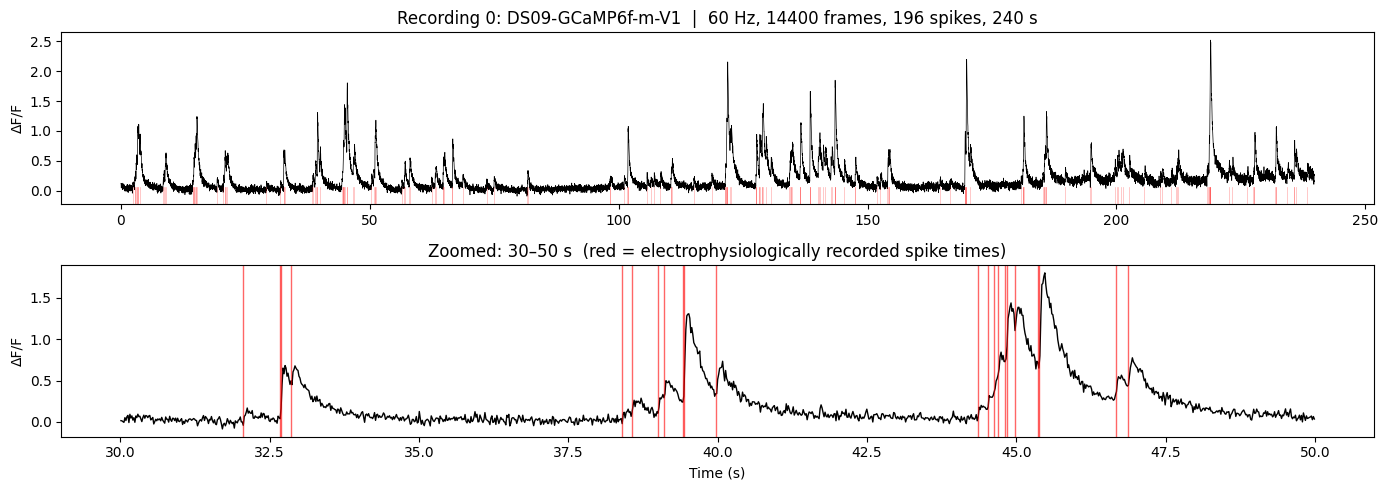

In [11]:
# Visualize an example training recording
idx = 0  # change this to browse different recordings
dff = data['train_dff'][idx]
t = data['train_t'][idx]
spikes = data['train_spikes'][idx]
fr = data['train_frame_rates'][idx]
ds_name = str(data['train_datasets'][idx])


fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Full trace
axes[0].plot(t, dff, 'k', linewidth=0.5)
for sp in spikes:
    axes[0].axvline(sp, color='red', alpha=0.3, linewidth=0.5, ymin=0, ymax=0.1)
axes[0].set_ylabel('ΔF/F')
axes[0].set_title(f'Recording {idx}: {ds_name}  |  {fr:.0f} Hz, {len(dff)} frames, '
                  f'{len(spikes)} spikes, {t[-1]:.0f} s')

# Zoomed window
t0, t1 = 30, 50
m = (t >= t0) & (t <= t1)
axes[1].plot(t[m], dff[m], 'k', linewidth=1)
for sp in spikes[(spikes >= t0) & (spikes <= t1)]:
    axes[1].axvline(sp, color='red', alpha=0.6, linewidth=1)
axes[1].set_ylabel('ΔF/F')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'Zoomed: {t0}–{t1} s  (red = electrophysiologically recorded spike times)')

plt.tight_layout()
plt.show()

## Checking baseline CASCADE performance on test data

##### 1. Loading ΔF/F traces

In [4]:
#@markdown ΔF/F traces must be saved as \*.npy-files (for Python) or \*.mat-files (for Matlab/Python) as a single large matrix named **`dF_traces`** (neurons x time). ΔF/F values of the input should be numeric, not in percent (e.g. 0.5 instead of 50%). For different input formats, the code in this box can be modified (it\'s not difficult).

def load_neurons_x_time(file_path):
    """Custom method to load data as 2d array with shape (neurons, nr_timepoints)"""

    if file_path.endswith('.mat'):
      traces = sio.loadmat(file_path)['dF_traces']
      # PLEASE NOTE: If you use mat73 to load large *.mat-file, be aware of potential numerical errors, see issue #67 (https://github.com/HelmchenLabSoftware/Cascade/issues/67)

    elif file_path.endswith('.npy'):
      traces = np.load(file_path, allow_pickle=True)
      # if saved data was a dictionary packed into a numpy array (MATLAB style): unpack
      if traces.shape == ():
        traces = traces.item()['dF_traces']

    else:
      raise Exception('This function only supports .mat or .npy files.')

    print('Traces standard deviation:', np.nanmean(np.nanstd(traces,axis=1)))
    if np.nanmedian(np.nanstd(traces,axis=1)) > 2:
      print('Fluctuations in dF/F are very large, probably dF/F is given in percent. Traces are divided by 100.')
      return traces/100
    else:
        return traces






##### 2. Select dataset, indicate frame rate, load traces and preprocess

In [38]:
def spikes_to_counts(spike_times, t):
    dt = t[1] - t[0]
    edges = np.append(t - dt/2, t[-1] + dt/2)
    counts, _ = np.histogram(spike_times, bins = edges)
    return counts.astype(float)

In [39]:
#Load data and resample to 30Hz
from scipy.signal import decimate
traces_list = data["test_dff"]
test_spikes = data["test_spikes"]
time = data["test_t"]
test_data = []


# downsample traces to 30 Hz

for i, t in enumerate(traces_list):
  test_data.append(decimate(t, 2))

np.save("trial.npy", test_data)

# adjust the time vectors to downsampes traces
spike_counts = spikes_to_counts(test_spikes[0], time[0])
resamp_spike_counts = (np.add.reduceat(spike_counts, np.arange(0, len(spike_counts), 2), axis=0))



In [ ]:
#@markdown If you are testing the script, you can leave everything unchanged. If you want to apply the algorithm to your own data, you have to upload your data first. The paragraph above tells you how to format and name the file. You can do this by clicking on the **folder symbol ("Files")** on the left side of the Colaboratory notebook. Next, indicate the path of the uploaded file in the variable **`example_file`**. Finally, indicate the sampling rate of your recordings in the variable **`frame_rate`**.



example_file = "trial.npy"

frame_rate = 30 #@param {type:"number"}

try:

  traces = load_neurons_x_time( example_file )
  print('Number of neurons in dataset:', traces.shape[0])
  print('Number of timepoints in dataset:', traces.shape[1])

except Exception as e:

  print('\nSomething went wrong!\nEither the target file is missing, in this case please provide the correct location.\nOr your file is not yet completely uploaded, in this case wait until the upload is completed.\n')

  print('Error message: '+str(e))


Traces standard deviation: 0.565371
Number of neurons in dataset: 9
Number of timepoints in dataset: 5000


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\janaurmi\AppData\Local\Temp\ipykernel_11156\2725859729.py:6: SyntaxWarning: invalid escape sequence '\s'
  traces_list = np.load("data\spike_inference_data.npz", allow_pickle=True)["test_dff"]


##### 3. Plot distribution of noise levels

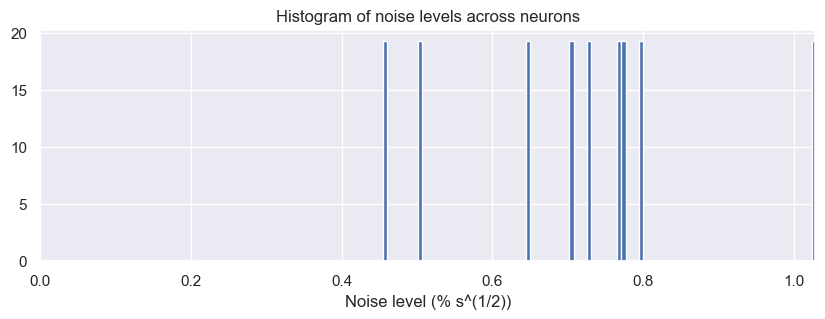

In [6]:
#@markdown For each neuron in the loaded dataset, the noise level will be computed and the distribution across neurons will be shown.
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = [10, 3]

noise_levels = plot_noise_level_distribution(traces,frame_rate)



##### 4. Plot calcium traces

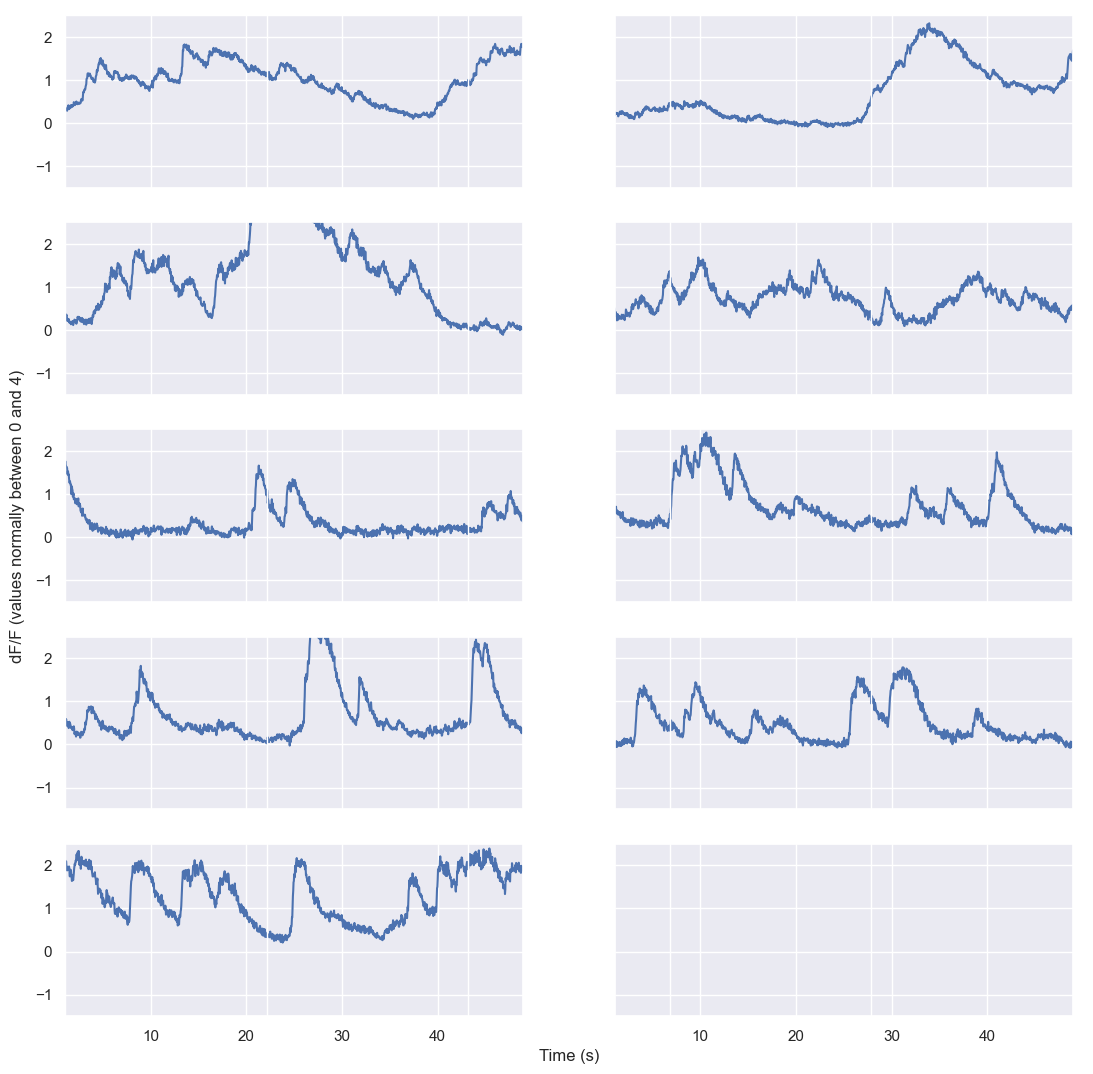

In [7]:
#@markdown Plotting random traces helps to check whether the data have been loaded correctly. If you want to plot specific instead of randomly selected neurons, modify the variable **`neuron_indices`** accordingly.


plt.rcParams['figure.figsize'] = [13, 13]


np.random.seed(3952)
neuron_indices = np.arange(0, len(traces))  #np.random.randint(traces.shape[0], size=9)
time_axis = plot_dFF_traces(traces,neuron_indices,frame_rate)


##### 5. Select Pretrained model from the CASCADE model zoo

In [30]:
#@markdown Get list of the names of available models.


cascade.download_model( 'update_models', model_folder=MODEL_FOLDER, verbose = 1)

MODEL_LIST = os.path.join(MODEL_FOLDER, "available_models_CascadeTorch.yaml")
yaml_file = open(MODEL_LIST)
X = yaml.load(yaml_file)
list_of_models = list(X.keys())
print('\n List of available models: \n')
for model in list_of_models:
  print(model)

You can now check the updated available_models_CascadeTorch.yaml file for valid model names.
File location: c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\CascadeTorch\Pretrained_models\available_models_CascadeTorch.yaml

 List of available models: 

GC8f_EXC_100Hz_smoothing10ms
GC8f_EXC_15Hz_smoothing100ms_high_noise
GC8f_EXC_15Hz_smoothing50ms_high_noise
GC8f_EXC_30Hz_smoothing25ms_high_noise
GC8f_EXC_30Hz_smoothing50ms_high_noise
GC8f_EXC_20Hz_smoothing40ms_high_noise
GC8f_EXC_7.5Hz_smoothing100ms_high_noise
GC8f_EXC_7.5Hz_smoothing200ms_high_noise
GC8m_EXC_15Hz_smoothing100ms_high_noise
GC8m_EXC_15Hz_smoothing50ms_high_noise
GC8m_EXC_30Hz_smoothing25ms_high_noise
GC8m_EXC_30Hz_smoothing50ms_high_noise
GC8m_EXC_7.5Hz_smoothing100ms_high_noise
GC8m_EXC_7.5Hz_smoothing200ms_high_noise
GC8s_EXC_15Hz_smoothing100ms_high_noise
GC8s_EXC_15Hz_smoothing50ms_high_noise
GC8s_EXC_20Hz_smoothing30ms_high_noise
GC8s_EXC_20Hz_smoothing60ms_high_noise
GC8s_EXC_30Hz_smoothing25ms_high_noise

In [32]:

# Select (from the list above) and download the model that fits to your dataset (frame rate, training data; see FAQ for more details) and assign to variable **`model_name`**.

model_name = "Global_EXC_30Hz_smoothing50ms_high_noise" #GC8s_EXC_30Hz_smoothing50ms_high_noise #@param {type:"string"}

cascade.download_model( model_name,model_folder=MODEL_FOLDER,verbose = 1)

Pretrained model was saved in folder "c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\CascadeTorch\Pretrained_models\Global_EXC_30Hz_smoothing50ms_high_noise"


##### 6. Predict and plot expected spikes from the traces

In [35]:
#@markdown If this takes too long, make sure that the GPU runtime is activated (*Menu > Runtime > Change Runtime Type*).

total_array_size = traces.itemsize*traces.size*64/1e9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If the expected array size is too large for the Colab Notebook, split up for processing
if total_array_size < 1:
  spike_prob = cascade.predict( model_name, traces, model_folder=MODEL_FOLDER, device=device, verbosity=1 )

# Will only be use for large input arrays (long recordings or many neurons)
else:

  print("Split analysis into chunks in order to fit into Colab memory.")

  # pre-allocate array for results
  spike_prob = np.zeros((traces.shape))
  # nb of neurons and nb of chuncks
  nb_neurons = traces.shape[0]
  nb_chunks = int(np.ceil(total_array_size/1))

  chunks = np.array_split(range(nb_neurons), nb_chunks)
  # infer spike rates independently for each chunk
  for part_array in range(nb_chunks):
    spike_prob[chunks[part_array],:] = cascade.predict( model_name, traces[chunks[part_array],:], device=device )



 
The selected model was trained on 18 datasets, with 5 ensembles for each noise level, at a sampling rate of 30Hz, with a resampled ground truth that was smoothed with a Gaussian kernel of a standard deviation of 50 milliseconds. 
 

Loaded model was trained at frame rate 30 Hz
Given argument traces contains 9 neurons and 5000 frames.
Noise levels (mean, std; in standard units): 0.71, 0.15

Predictions for noise level 2:
	... ensemble 0
	... ensemble 1
	... ensemble 2
	... ensemble 3
	... ensemble 4

Predictions for noise level 3:
	No neurons for this noise level

Predictions for noise level 4:
	No neurons for this noise level

Predictions for noise level 5:
	No neurons for this noise level

Predictions for noise level 6:
	No neurons for this noise level

Predictions for noise level 7:
	No neurons for this noise level

Predictions for noise level 8:
	No neurons for this noise level

Predictions for noise level 9:
	No neurons for this noise level

Predictions for noise level 10:
	No n

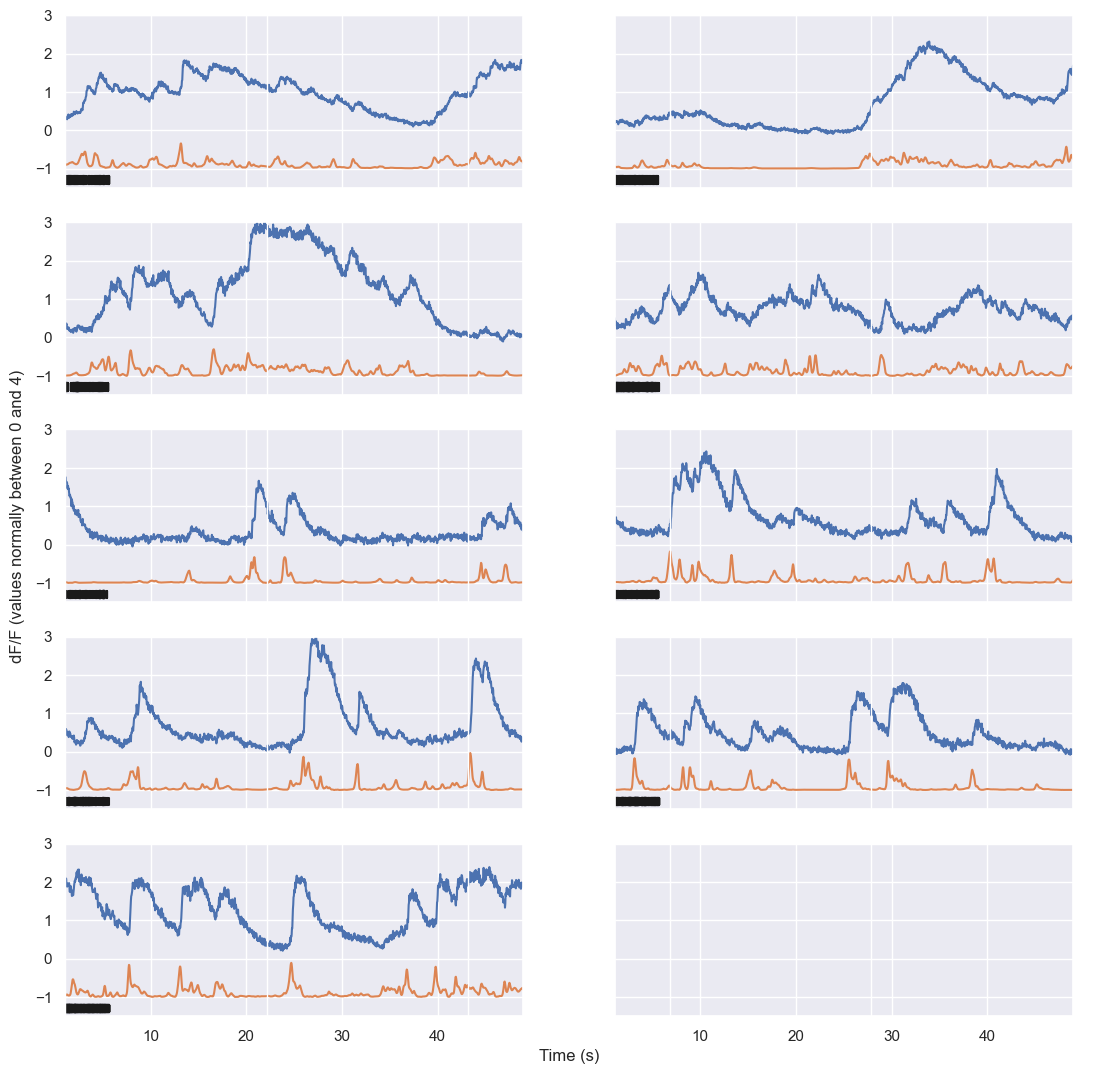

In [41]:
# plot expected spike probabilites as predicted 
#@markdown Plot first seconda of the test neurons. The dF/F traces are shown in blue, the inferred spike probability is plotted in orange (shifted downwards by 1 for better visibility).

neuron_indices = np.arange(0, len(traces)) #np.random.randint(traces.shape[0], size=nb_neurons)
time_axis = plot_dFF_traces(traces,neuron_indices,frame_rate, spike_prob,y_range=(-1.5, 3), discrete_spikes= test_spikes)

<Figure size 1000x500 with 0 Axes>

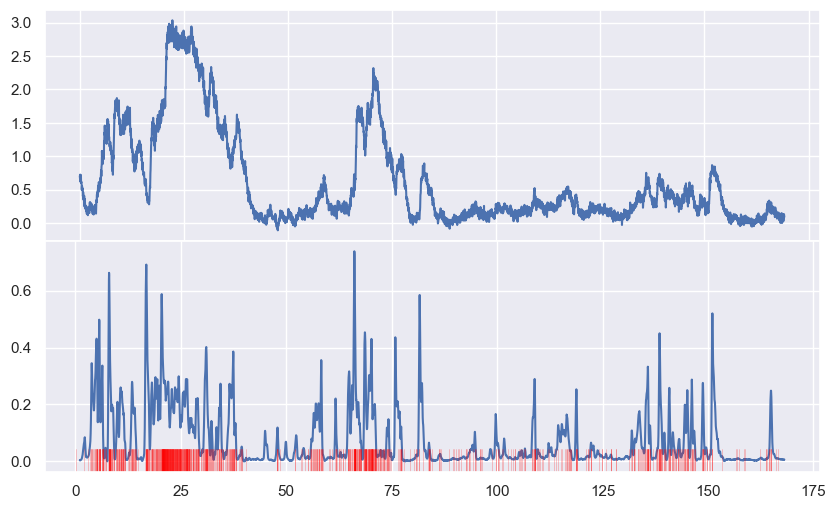

In [45]:
# plots for downsampled spike trace, predicted spikes and ground truth spikes
plt.figure(figsize=(10,5))
fig, axs = plt.subplots(
    2, 1, figsize=(10, 6), height_ratios=[ 1, 1], gridspec_kw=dict(hspace=0)
)

idx=2
t = time[idx][::2]
axs[0].plot(t, traces[idx])
axs[1].plot(t, spike_prob[idx])
# axs[1].plot(resamp_spike_counts)
for sp in test_spikes[idx]:
    axs[1].axvline(sp, color='red', alpha=0.3, linewidth=0.5, ymin=0, ymax=0.1)

##### 7. Measure correlation with ground truth

In [46]:
ok = np.isfinite(spike_prob[0]) & np.isfinite(resamp_spike_counts)
np.corrcoef(spike_prob[0][ok], resamp_spike_counts[ok])[0, 1]
# traces[0].shape, resamp_spike_counts.shape, spike_prob[0].shape

np.float64(0.36030496803448536)